## Histogram Manipulation and Equalization --


In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

Here is our first test image. First, we load it using OpenCV’s imread function in grayscale mode.


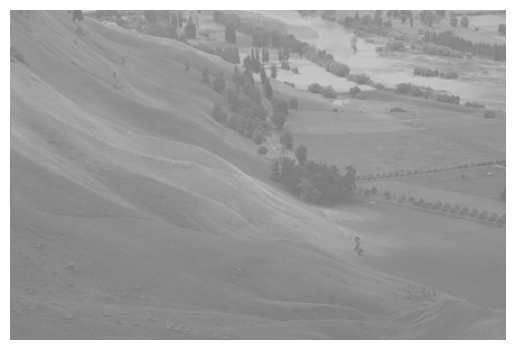

In [9]:
path = "vallee.png"
img = cv.imread(path, cv.IMREAD_GRAYSCALE)  # lecture de l'image avec openCV , cv.imread  fonction pour lire l'image ,  IMREAD_GRAYSCALE : iindique de charger l'image en niveau de gris 
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off") 
plt.show()

## Why we flatten the Array image before processing?

Flattening is a technique that is used to convert multi-dimensional arrays into a 1-D array,
Multi-Dimensional arrays take more amount of memory while 1-D arrays take less memory, which
is the most important reason why we flatten the Image Array before processing.


C:\Users\MSI\AppData\Local\Temp\ipykernel_20036\1785164968.py:6: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256], color = 'r')


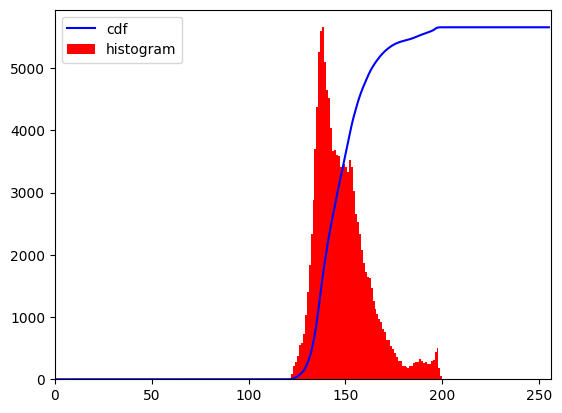

In [ ]:
hist,bins = np.histogram(img.flatten(),256,[0,256])  # transforme l'image (matrice) en une vecteur (1D) contenant tous les pixels
cdf = hist.cumsum()
#cdf= Cumulative Distribution Function of an image
cdf_normalized = cdf * float(hist.max()) / cdf.max()
plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

## Observation and Interpretation of the Histogram and Image Contrast

We observe that the gray levels of the image are mainly distributed in the approximate range \([125, 200]\), with a peak around 140. The histogram shows a bell-shaped distribution, meaning that most pixel intensities are concentrated around mid-gray values.

The cumulative distribution function (CDF) increases rapidly within the same range, confirming that most of the image information is concentrated in a limited portion of the intensity spectrum.

## Conclusion

The image has **low to moderate contrast**, since the pixel values are not spread over the full range \([0, 255]\). Instead, they are clustered in a relatively narrow interval. This compression of intensity levels leads to reduced contrast and a less visually dynamic image.

As a **result of low contrast**, the human eye has difficulty clearly distinguishing the details of an image.


## Equalized Histogram


C:\Users\MSI\AppData\Local\Temp\ipykernel_20036\715129920.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(), 256, [0,256])
C:\Users\MSI\AppData\Local\Temp\ipykernel_20036\715129920.py:31: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(equ.flatten(), 256, [0,256])


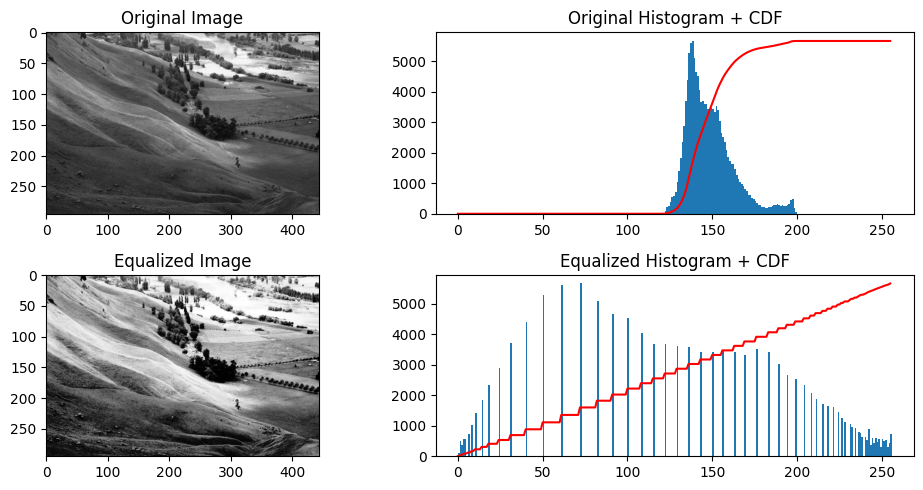

In [13]:


# Égalisation d'histogramme
equ = cv.equalizeHist(img)

# Histogramme + CDF pour image originale
hist, bins = np.histogram(img.flatten(), 256, [0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max() / cdf.max()

# Histogramme + CDF pour image égalisée
hist_equ, bins = np.histogram(equ.flatten(), 256, [0,256])
cdf_equ = hist_equ.cumsum()
cdf_equ_normalized = cdf_equ * hist_equ.max() / cdf_equ.max()

# Affichage
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")

plt.subplot(2,2,2)
plt.hist(img.flatten(), 256, [0,256])
plt.plot(cdf_normalized, color='red')
plt.title("Original Histogram + CDF")

plt.subplot(2,2,3)
plt.imshow(equ, cmap='gray')
plt.title("Equalized Image")

plt.subplot(2,2,4)
plt.hist(equ.flatten(), 256, [0,256])
plt.plot(cdf_equ_normalized, color='red')
plt.title("Equalized Histogram + CDF")

plt.tight_layout()
plt.show()

## Observation and Interpretation

We now observe that the details of the image are more visible. This improvement is due to **histogram equalization**, which works by spreading the intensity values across the entire range of gray levels, thus enhancing the contrast.

## Mathematical Explanation

$$ s_k = (L - 1) \cdot \text{CDF}(r_k) $$

For each pixel, we compute the cumulative histogram function (CDF):

- If the **CDF is low**, then $s_k$ is low → the pixel becomes **darker**
- If the **CDF is high**, then $s_k$ is high → the pixel becomes **lighter**

### Special cases:

- When $\text{CDF}(r_k) = 0$ (no pixels have a gray level lower than this one) → $s_k = 0$ (black)
- When $\text{CDF}(r_k) = 1$ (all pixels have a gray level lower than or equal to this one) → $s_k = 255$ (white)

For intermediate CDF values (between 0 and 1), the resulting $s_k$ values are **spread across the entire interval [0, 255]**.

### Conclusion:

- Good spread across all gray levels
- High contrast
- Better visibility


## Adaptive Histogram Equalization (AHE)

**Adaptive Histogram Equalization (AHE)** is a contrast enhancement method that applies histogram equalization **locally** instead of applying it to the entire image.

The classical histogram equalization method (global) processes the whole image using a single histogram.
AHE, on the other hand, **divides** the image into several **small regions** and applies equalization separately to each region.


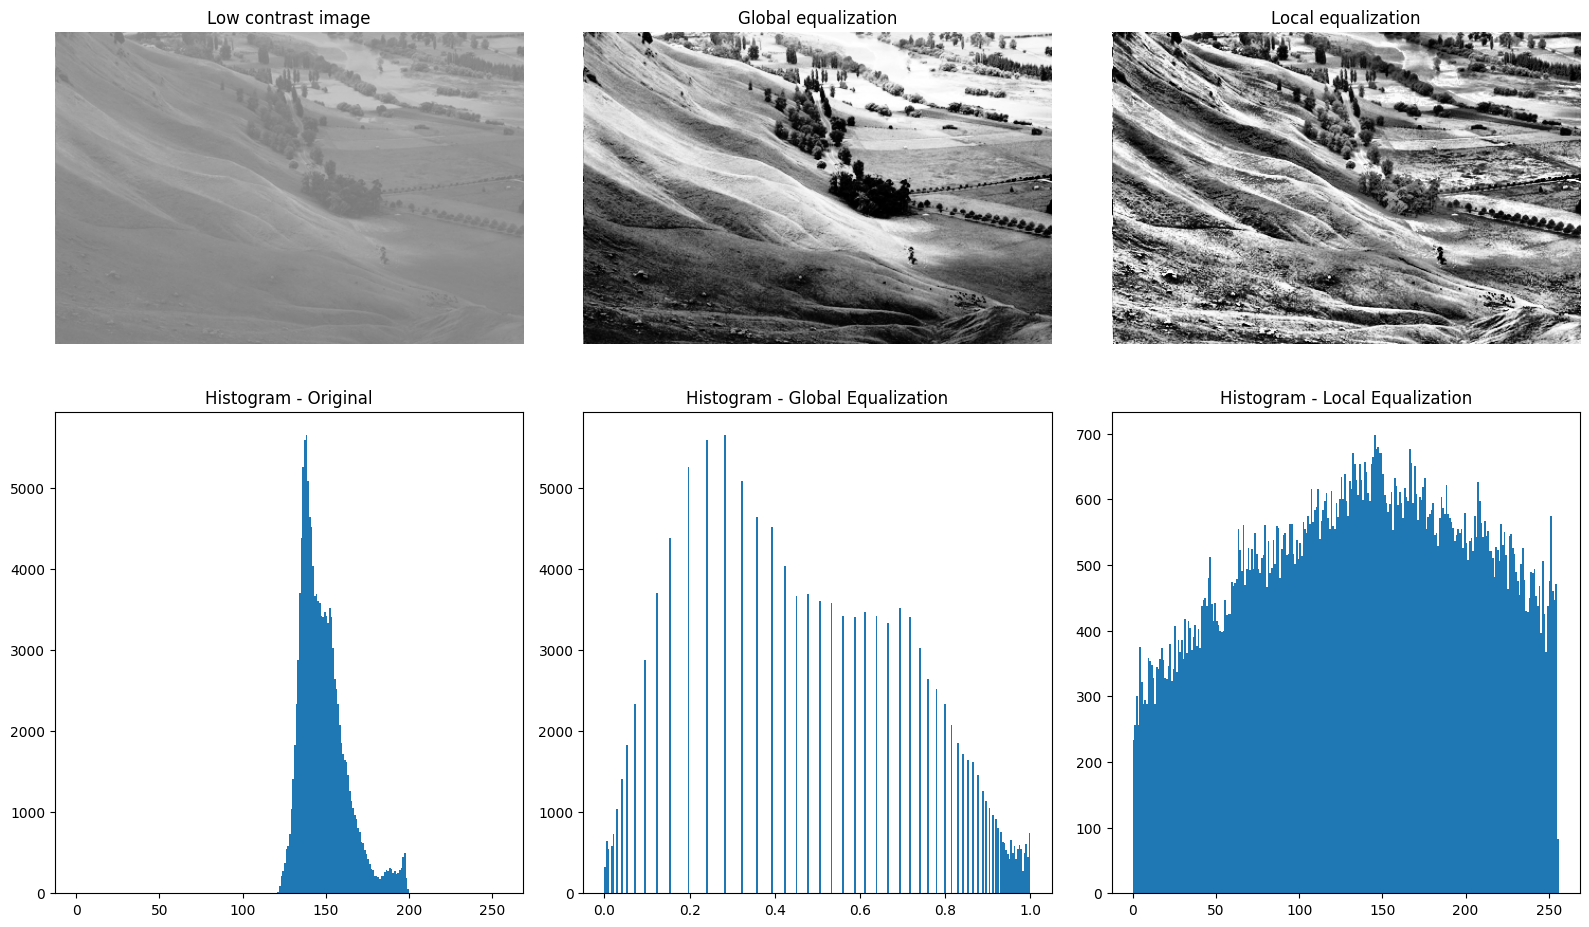

In [ ]:
from skimage.util import img_as_ubyte
from skimage import exposure
import skimage.morphology as morp
from skimage.filters import rank
from skimage.io import imread

# Original image
img = img_as_ubyte(imread(path, as_gray=True))

# Global equalization
img_global = exposure.equalize_hist(img)

# Local Equalization (Adaptive Histogram Equalization)
kernel = morp.disk(30)
img_local = rank.equalize(img, footprint=kernel)

plt.rcParams['figure.figsize'] = [16,10]

# --- Layout ---
fig, axes = plt.subplots(2,3)

ax_img, ax_global, ax_local = axes[0]
ax_hist1, ax_hist2, ax_hist3 = axes[1]

# --- Images ---
ax_img.imshow(img, cmap='gray', vmin=0, vmax=255)
ax_img.set_title('Low contrast image')
ax_img.axis('off')

ax_global.imshow(img_global, cmap='gray', vmin=0, vmax=1)
ax_global.set_title('Global equalization')
ax_global.axis('off')

ax_local.imshow(img_local, cmap='gray', vmin=0, vmax=255)
ax_local.set_title('Local equalization')
ax_local.axis('off')

# --- Histograms ---
ax_hist1.hist(img.ravel(), bins=256, range=(0,256))
ax_hist1.set_title('Histogram - Original')

ax_hist2.hist(img_global.ravel(), bins=256, range=(0,1))
ax_hist2.set_title('Histogram - Global Equalization')

ax_hist3.hist(img_local.ravel(), bins=256, range=(0,256))
ax_hist3.set_title('Histogram - Local Equalization')

plt.tight_layout()
plt.show()

## Observation and Interpretation

Compared with global histogram equalization, the image obtained using **local (adaptive) histogram equalization** shows **clearer and more visible details.**

This improvement occurs because the equalization process is applied **locally on small regions of the image rather than on the entire image at once**. Each region has its own histogram and contrast adjustment. As a result, the contrast is enhanced **within each local area**, which helps reveal structures and edges that may remain hidden with global equalization.

Consequently, adaptive histogram equalization improves the **visibility of fine details** across different parts of the image. However, this method may also **increase the level of noise**, especially in relatively uniform regions, because local contrast enhancement can amplify small intensity variations.


## Contrastive Limited Adaptive Equalization


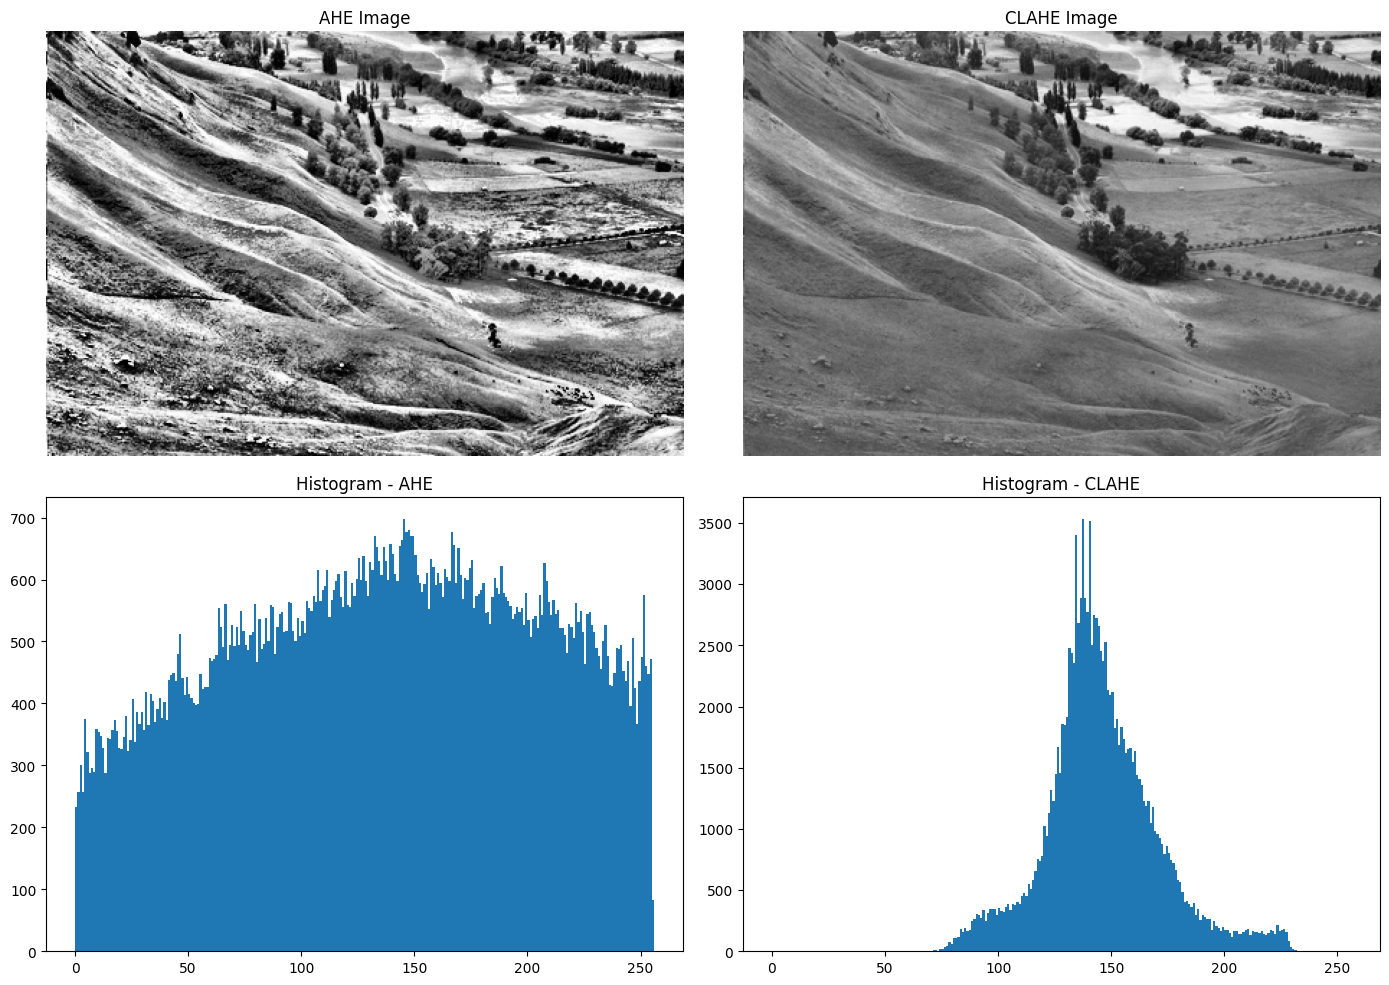

In [ ]:
img = img_as_ubyte(imread(path, as_gray=True))

# AHE (Adaptive Histogram Equalization)

kernel = morp.disk(30)
ahe = rank.equalize(img, footprint=kernel)

# CLAHE (Contrast Limited AHE)

clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

# Plot images + histograms

plt.figure(figsize=(14,10))

# Images
plt.subplot(2,2,1)
plt.imshow(ahe, cmap='gray')
plt.title("AHE Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE Image")
plt.axis("off")

# Histograms
plt.subplot(2,2,3)
plt.hist(ahe.ravel(), bins=256, range=(0,256))
plt.title("Histogram - AHE")

plt.subplot(2,2,4)
plt.hist(clahe_img.ravel(), bins=256, range=(0,256))
plt.title("Histogram - CLAHE")

plt.tight_layout()
plt.show()

CLAHE is an improvement of AHE that addresses its main drawback: **excessive noise amplification**.

Unlike AHE, CLAHE introduces a **clip limit** parameter that controls the amount of contrast enhancement applied to the image. Before computing the CDF, the histogram is **clipped at a predefined threshold**, preventing very frequent intensity values from dominating the transformation.

By limiting extreme peaks in the histogram, CLAHE ensures a more **balanced contrast enhancement**, preserving image details while reducing noise amplification.

As a result, CLAHE provides a more stable and visually natural enhancement compared to standard AHE.
